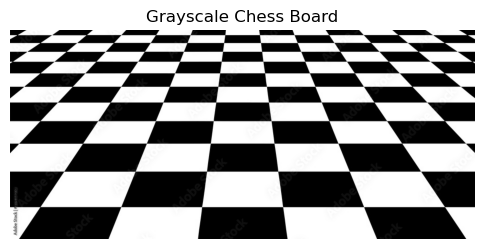

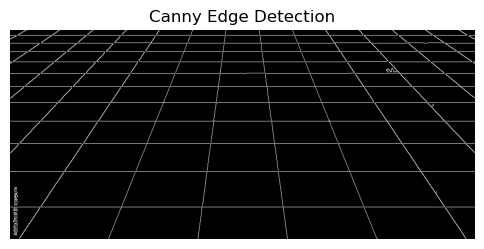

Canny Edge Detector Parameters: threshold1=50, threshold2=150


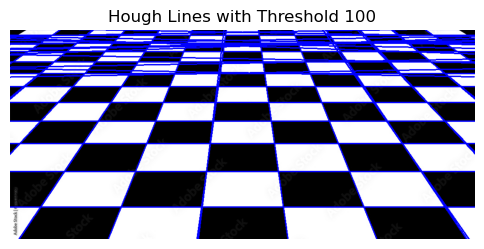

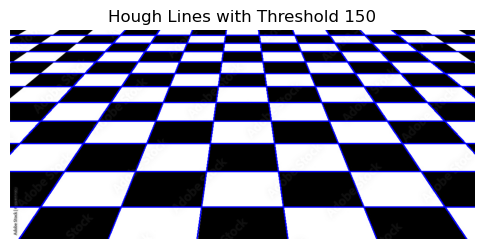

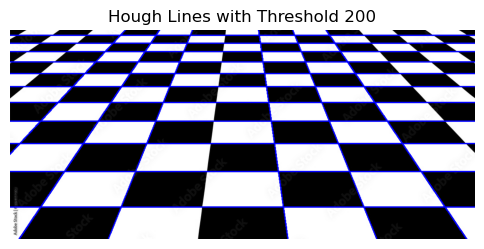

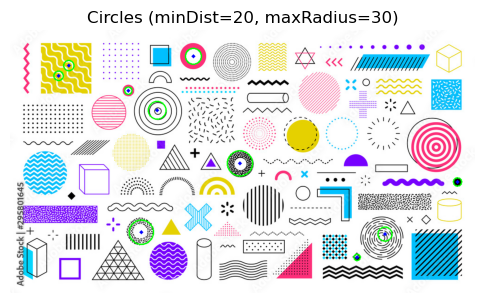

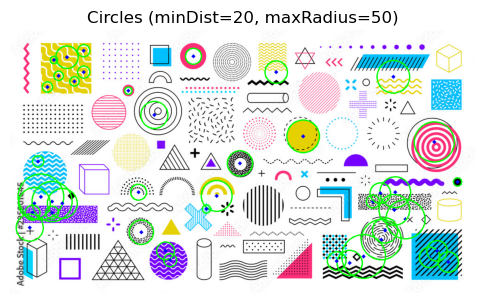

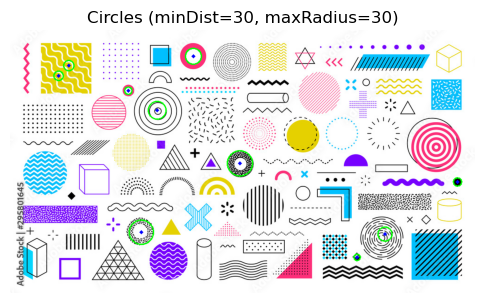

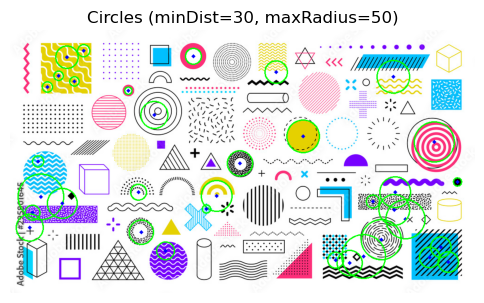

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to display images
def show_image(title, image, cmap_type='gray'):
    plt.figure(figsize=(6, 6))
    plt.title(title)
    plt.imshow(image, cmap=cmap_type)
    plt.axis('off')
    plt.show()

# 1. Load 'Chess_Board' image and convert to grayscale
chess_board_img = cv2.imread('images/Chess_Board.jpg')
chess_board_gray = cv2.cvtColor(chess_board_img, cv2.COLOR_BGR2GRAY)
show_image('Grayscale Chess Board', chess_board_gray)

# 2. Apply Canny edge detector
canny_edges = cv2.Canny(chess_board_gray, 50, 150)
show_image('Canny Edge Detection', canny_edges)
print("Canny Edge Detector Parameters: threshold1=50, threshold2=150")

# 3. Hough Line Transform with varying thresholds
threshold_values = [100, 150, 200]
for threshold in threshold_values:
    lines = cv2.HoughLines(canny_edges, 1, np.pi / 180, threshold)
    line_img = chess_board_img.copy()
    if lines is not None:
        for rho, theta in lines[:, 0]:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(line_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    show_image(f'Hough Lines with Threshold {threshold}', line_img, cmap_type=None)

# 4. Explanation of threshold
#Threshold in Hough Line Transform determines the minimum number of intersections in the accumulator to detect a line. Higher thresholds detect fewer lines, focusing on stronger edges.

# 5. Load 'Geometric_Shapes' image and apply Hough Circle Transform
geo_shapes_img = cv2.imread('images/Geometric_Shapes.jpg')
geo_shapes_gray = cv2.cvtColor(geo_shapes_img, cv2.COLOR_BGR2GRAY)
geo_shapes_blur = cv2.medianBlur(geo_shapes_gray, 5)

minDist_values = [20, 30]
maxRadius_values = [30, 50]

for minDist in minDist_values:
    for maxRadius in maxRadius_values:
        circles = cv2.HoughCircles(geo_shapes_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=minDist,
                                   param1=100, param2=30, minRadius=0, maxRadius=maxRadius)
        circle_img = geo_shapes_img.copy()
        if circles is not None:
            circles = np.uint16(np.around(circles))
            for i in circles[0, :]:
                cv2.circle(circle_img, (i[0], i[1]), i[2], (0, 255, 0), 2)
                cv2.circle(circle_img, (i[0], i[1]), 2, (0, 0, 255), 3)
        show_image(f'Circles (minDist={minDist}, maxRadius={maxRadius})', circle_img, cmap_type=None)

# 6. Explanation of HoughCircles parameters
#In cv.HoughCircles():
#minDist controls the minimum distance between detected circle centers. Smaller values may detect overlapping circles.
#maxRadius limits the maximum size of circles to detect. Larger values allow detection of bigger circles.
#param2 is the accumulator threshold for circle centers. Higher values detect fewer circles with stronger evidence.